# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [61]:
# importar librerías
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Análisis estadístico
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
print("=" * 50)
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [7]:
# información general
print("\n" + "=" * 50)
print(" DIMENSIONES DEL DATASET:")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

print("\n" + "=" * 50)
print(" TIPOS DE DATOS:")
print(df.dtypes)

print("\n" + "=" * 50)
print("VALORES NULOS POR COLUMNA:")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
# Antes de la conversión
print("Tipo de dato ANTES:")
print(f"date: {df['date'].dtype}")

# Conversión
df['date'] = pd.to_datetime(df['date'])

# Después de la conversión
print("\nTipo de dato DESPUÉS:")
print(f"date: {df['date'].dtype}")

# Verificar el rango de fechas
print(f"\nRANGO DE FECHAS DEL EXPERIMENTO:")
print(f"Fecha inicial: {df['date'].min()}")
print(f"Fecha final: {df['date'].max()}")
print(f"Duración: {(df['date'].max() - df['date'].min()).days} días")


 DIMENSIONES DEL DATASET:
Filas: 40,000
Columnas: 9

 TIPOS DE DATOS:
user_id            object
date               object
landing            object
region             object
dispositivo        object
traffic_source     object
user_type          object
converted           int64
gasto             float64
dtype: object

VALORES NULOS POR COLUMNA:
user_id           0
date              0
landing           0
region            0
dispositivo       0
traffic_source    0
user_type         0
converted         0
gasto             0
dtype: int64

Tipo de dato ANTES:
date: object

Tipo de dato DESPUÉS:
date: datetime64[ns]

RANGO DE FECHAS DEL EXPERIMENTO:
Fecha inicial: 2026-01-01 00:00:00
Fecha final: 2026-01-28 00:00:00
Duración: 27 días


✍️ **Comentario**: Haz doble clic en este bloque y escribe qué ves
- Si hay errores como valores nulos o columna con tipo de dato incorrecto, define pasos a seguir. Por ejemplo:
    - Se observan X valores nulos en la columnna ...
    - La columna ... es de tipo de dato ... y debería de ser ... .
- Si no hay errores señalalo y continúa con el proceso. Por ejemplo:
    - El dataset no tiene valores ausentes.
    
 Comienza a escribir debajo de este texto, una vez escritas tus conclusiones, **elimina estas instrucciones** (de aqui hacia arriba de este bloque) para dejar solamente tus hallazgos.

 La columna date aparece como object en lugar de datetime

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [8]:
# Verificar usuarios únicos
print("=== VERIFICACIÓN DE USUARIOS ÚNICOS ===")
print(f"Total de filas en el dataset: {len(df):,}")
print(f"Usuarios únicos: {df['user_id'].nunique():,}")
print(f"¿Hay usuarios duplicados?: {'SÍ' if len(df) != df['user_id'].nunique() else 'NO'}")

# Si hay duplicados, investigar más
if len(df) != df['user_id'].nunique():
    duplicados = df[df.duplicated(subset=['user_id'], keep=False)]
    print(f"\nUsuarios con registros duplicados: {duplicados['user_id'].nunique()}")
    print("Ejemplo de usuario duplicado:")
    print(duplicados.head())

=== VERIFICACIÓN DE USUARIOS ÚNICOS ===
Total de filas en el dataset: 40,000
Usuarios únicos: 40,000
¿Hay usuarios duplicados?: NO


 **Variable `date`**  
Explorar rango de fechas

In [9]:
# Resumen estadístico
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [12]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())
print(f"Duración total: {(df['date'].max() - df['date'].min()).days} días")
# Distribución de usuarios por día
print(f"\n DISTRIBUCIÓN DIARIA DE USUARIOS:")
usuarios_por_dia = df['date'].value_counts().sort_index()
print(f"Promedio de usuarios por día: {usuarios_por_dia.mean():.1f}")
print(f"Mínimo de usuarios en un día: {usuarios_por_dia.min()}")
print(f"Máximo de usuarios en un día: {usuarios_por_dia.max()}")

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00
Duración total: 27 días

📊 DISTRIBUCIÓN DIARIA DE USUARIOS:
Promedio de usuarios por día: 1428.6
Mínimo de usuarios en un día: 1363
Máximo de usuarios en un día: 1512


**Variable `gasto` (numérica)**

In [13]:
# Resumen estadístico
# === RESUMEN ESTADÍSTICO DE LA VARIABLE GASTO ===
print("=== ANÁLISIS ESTADÍSTICO: VARIABLE GASTO ===")
print("=" * 50)

# Estadísticas descriptivas completas
print("📊 ESTADÍSTICAS DESCRIPTIVAS:")
print(df['gasto'].describe())

print(f"\n💡 MÉTRICAS ADICIONALES:")
print(f"Gasto total del experimento: ${df['gasto'].sum():,.2f}")
print(f"Usuarios con gasto > 0: {(df['gasto'] > 0).sum():,}")
print(f"Usuarios sin gasto: {(df['gasto'] == 0).sum():,}")
print(f"Porcentaje de usuarios que gastaron: {(df['gasto'] > 0).mean()*100:.2f}%")

# Análisis de distribución
print(f"\n📈 ANÁLISIS DE DISTRIBUCIÓN:")
print(f"Mediana del gasto: ${df['gasto'].median():.2f}")
print(f"Gasto promedio (solo usuarios que gastaron): ${df[df['gasto'] > 0]['gasto'].mean():.2f}")

=== ANÁLISIS ESTADÍSTICO: VARIABLE GASTO ===
📊 ESTADÍSTICAS DESCRIPTIVAS:
count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

💡 MÉTRICAS ADICIONALES:
Gasto total del experimento: $373,022.15
Usuarios con gasto > 0: 5,706
Usuarios sin gasto: 34,294
Porcentaje de usuarios que gastaron: 14.27%

📈 ANÁLISIS DE DISTRIBUCIÓN:
Mediana del gasto: $0.00
Gasto promedio (solo usuarios que gastaron): $65.37


In [14]:
# Resumen estadístico de usuarios que se convirtieron
# === ANÁLISIS ESTADÍSTICO: VARIABLE CONVERTED ===
print("=== ANÁLISIS DE CONVERSIONES ===")
print("=" * 40)

# Análisis de conversiones
print("📊 ESTADÍSTICAS DE CONVERSIÓN:")
conversiones = df['converted'].value_counts()
print(conversiones)

print(f"\n💡 MÉTRICAS DE CONVERSIÓN:")
tasa_conversion = df['converted'].mean()
print(f"Tasa de conversión general: {tasa_conversion*100:.2f}%")
print(f"Usuarios convertidos: {df['converted'].sum():,}")
print(f"Usuarios NO convertidos: {(df['converted'] == 0).sum():,}")

# Relación entre conversión y gasto
print(f"\n🔍 RELACIÓN CONVERSIÓN vs GASTO:")
usuarios_convertidos_con_gasto = ((df['converted'] == 1) & (df['gasto'] > 0)).sum()
usuarios_convertidos_sin_gasto = ((df['converted'] == 1) & (df['gasto'] == 0)).sum()

print(f"Usuarios convertidos CON gasto: {usuarios_convertidos_con_gasto:,}")
print(f"Usuarios convertidos SIN gasto: {usuarios_convertidos_sin_gasto:,}")
print(f"% de convertidos que también gastaron: {(usuarios_convertidos_con_gasto/df['converted'].sum())*100:.2f}%")

=== ANÁLISIS DE CONVERSIONES ===
📊 ESTADÍSTICAS DE CONVERSIÓN:
0    34294
1     5706
Name: converted, dtype: int64

💡 MÉTRICAS DE CONVERSIÓN:
Tasa de conversión general: 14.27%
Usuarios convertidos: 5,706
Usuarios NO convertidos: 34,294

🔍 RELACIÓN CONVERSIÓN vs GASTO:
Usuarios convertidos CON gasto: 5,706
Usuarios convertidos SIN gasto: 0
% de convertidos que también gastaron: 100.00%


 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [16]:
# Explorar variables categóricas y cómo se distribuyen
#print("\nConteo de categorías:")
#print(#completa el código)
    # === ANÁLISIS DE VARIABLES CATEGÓRICAS ===
print("=" * 50)
print("📊 ANÁLISIS DE VARIABLES CATEGÓRICAS")
print("=" * 50)

# 1. Análisis de la variable principal del experimento: landing (A vs B)
print("\n🎯 DISTRIBUCIÓN DEL EXPERIMENTO A/B:")
print("-" * 40)
landing_counts = df['landing'].value_counts()
print(landing_counts)

# Calcular porcentajes
landing_pct = df['landing'].value_counts(normalize=True) * 100
print(f"\n📊 PORCENTAJES:")
for grupo, porcentaje in landing_pct.items():
    print(f"Grupo {grupo}: {porcentaje:.2f}%")

# Verificar balance del experimento
print(f"\n⚖️ BALANCE DEL EXPERIMENTO:")
diferencia_pct = abs(landing_pct['A'] - landing_pct['B'])
print(f"Diferencia entre grupos: {diferencia_pct:.2f}%")
if diferencia_pct <= 5:
    print("✅ Experimento BALANCEADO (diferencia ≤ 5%)")
else:
    print("⚠️ Experimento DESBALANCEADO (diferencia > 5%)")

    # 2. Análisis de otras variables categóricas importantes
print("\n" + "=" * 50)
print("🔍 OTRAS VARIABLES CATEGÓRICAS")
print("=" * 50)

# Variables categóricas a analizar
variables_categoricas = ['region', 'dispositivo', 'traffic_source', 'user_type']

for variable in variables_categoricas:
    print(f"\n📋 DISTRIBUCIÓN DE {variable.upper()}:")
    print("-" * 30)
    
    # Conteos absolutos
    conteos = df[variable].value_counts()
    print(conteos)
    
    # Porcentajes
    porcentajes = df[variable].value_counts(normalize=True) * 100
    print(f"\n📊 Porcentajes:")
    for categoria, pct in porcentajes.items():
        print(f"  {categoria}: {pct:.2f}%")
    
    print("-" * 30)

📊 ANÁLISIS DE VARIABLES CATEGÓRICAS

🎯 DISTRIBUCIÓN DEL EXPERIMENTO A/B:
----------------------------------------
B    20018
A    19982
Name: landing, dtype: int64

📊 PORCENTAJES:
Grupo B: 50.04%
Grupo A: 49.95%

⚖️ BALANCE DEL EXPERIMENTO:
Diferencia entre grupos: 0.09%
✅ Experimento BALANCEADO (diferencia ≤ 5%)

🔍 OTRAS VARIABLES CATEGÓRICAS

📋 DISTRIBUCIÓN DE REGION:
------------------------------
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

📊 Porcentajes:
  Norte: 27.91%
  Centro: 24.03%
  Sur: 20.10%
  Occidente: 16.00%
  Oriente: 11.96%
------------------------------

📋 DISTRIBUCIÓN DE DISPOSITIVO:
------------------------------
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

📊 Porcentajes:
  Mobile: 62.07%
  Desktop: 37.93%
------------------------------

📋 DISTRIBUCIÓN DE TRAFFIC_SOURCE:
------------------------------
Organic     17987
Ads         11935
Email        6123
Referral   

EXPERIMENTO A/B - ANÁLISIS PRINCIPAL

✅ Balance perfecto del experimento:

    Grupo A: 49.95% (19,982 usuarios)
    Grupo B: 50.04% (20,018 usuarios)
    Diferencia: solo 0.09% - ¡Prácticamente perfecto!

Esto es fundamental porque garantiza que cualquier diferencia en resultados se debe al tratamiento, no a desbalances en la muestra.
📊 ANÁLISIS DE VARIABLES DEMOGRÁFICAS

1. Distribución Regional:

    Norte domina con 27.91% - la región más activa
    Centro sigue con 24.03%
    Distribución decreciente: Norte > Centro > Sur > Occidente > Oriente
    Esto sugiere diferentes niveles de penetración digital por región

2. Dispositivos:

    Mobile predomina con 62.07% vs Desktop 37.93%
    Refleja el comportamiento actual del consumidor digital
    Importante para el diseño responsive de las landing pages

3. Fuentes de Tráfico:

    Organic lidera con 44.97% - buen SEO/brand awareness
    Ads representa 29.84% - inversión publicitaria significativa
    Email 15.31% y Referral 9.89% - canales complementarios

4. Tipo de Usuario:

    Nuevos usuarios 65.08% vs Recurrentes 34.92%
    Indica que el sitio está atrayendo mucho tráfico nuevo

✍️ **Comentario**: Haz doble clic en este bloque y escribe qué ves
- Si hay errores como categorías mal escritas, define pasos a seguir. Por ejemplo:
    - Hay valores negativos/no esperados en la columna X.
- Si no hay errores señalalo y continúa con el proceso. Por ejemplo:
    - Todas las columnas tienen valores esperados.

Comienza a escribir debajo de este texto, una vez escritas tus conclusiones, **elimina estas instrucciones** (de aqui hacia arriba de este bloque) para dejar solamente tus hallazgos.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [30]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']#completa el código
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']#completa el código

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)



(2512, 3194)

In [31]:
print(f"Gasto promedio Grupo A: ${gasto_A.mean():.2f}")
print(f"Gasto promedio Grupo B: ${gasto_B.mean():.2f}")

Gasto promedio Grupo A: $61.09
Gasto promedio Grupo B: $68.75


### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [32]:
# Aplicar prueba
# Primero, asegúrate de tener los datos de gasto para cada grupo (solo convertidos)
gasto_grupo_a = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_grupo_b = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Importar la función necesaria
from scipy.stats import ttest_ind

# Aplicar prueba
estadistico, valor_p = ttest_ind(gasto_grupo_a, gasto_grupo_b)

# Visualizar resultados
print(f"Estadístico: {estadistico:.4f}")
print(f"Valor p: {valor_p:.4f}")

Estadístico: -9.3656
Valor p: 0.0000


In [59]:
# Estadísticas descriptivas
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(f"Página A - Gasto promedio: ${gasto_grupo_a.mean():.2f}")
print(f"Página A - Mediana: ${gasto_grupo_a.median():.2f}")
print(f"Página A - Desviación estándar: ${gasto_grupo_a.std():.2f}")
print(f"Página A - Tamaño muestra: {len(gasto_grupo_a)}")

print(f"\nPágina B - Gasto promedio: ${gasto_grupo_b.mean():.2f}")
print(f"Página B - Mediana: ${gasto_grupo_b.median():.2f}")
print(f"Página B - Desviación estándar: ${gasto_grupo_b.std():.2f}")
print(f"Página B - Tamaño muestra: {len(gasto_grupo_b)}")

=== ESTADÍSTICAS DESCRIPTIVAS ===
Página A - Gasto promedio: $61.09
Página A - Mediana: $55.84
Página A - Desviación estándar: $28.88
Página A - Tamaño muestra: 2512

Página B - Gasto promedio: $68.75
Página B - Mediana: $62.57
Página B - Desviación estándar: $32.00
Página B - Tamaño muestra: 3194


In [37]:
# Decisión sobre la hipótesis nula
alpha = 0.05
if valor_p < alpha:
    print(f"Decisión: RECHAZAMOS la hipótesis nula (valor_p = {valor_p:.4f} < α = {alpha})")
    print("Conclusión: Existe evidencia estadística suficiente de que hay diferencia significativa entre los grupos A y B")
else:
    print(f"Decisión: NO RECHAZAMOS la hipótesis nula (valor_p = {valor_p:.4f} >= α = {alpha})")
    print("Conclusión: No hay evidencia estadística suficiente para afirmar que existe diferencia entre los grupos")

Decisión: RECHAZAMOS la hipótesis nula (valor_p = 0.0000 < α = 0.05)
Conclusión: Existe evidencia estadística suficiente de que hay diferencia significativa entre los grupos A y B


### Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

RECHAZAMOS la hipótesis nula (valor_p = 0.0000 < α = 0.05)
Conclusión: Existe evidencia estadística suficiente de que hay diferencia significativa entre los grupos A y B

**Interpretación de negocio:**  
Explica con tus propias palabras qué indican estos resultados sobre el gasto promedio entre la página A y la página B.

INTERPRETACIÓN DETALLADA DE LOS RESULTADOS
1. Análisis de las Tasas de Conversión:

Grupo A (Página Original): 12.57%
Grupo B (Página Nueva): 15.96%
Diferencia: +3.38 puntos porcentuales a favor de B
2. Significado Práctico:

 La página B es 27% más efectiva que la página A
- Cálculo: (15.96% - 12.57%) / 12.57% = 27% de mejora relativa

 Impacto en números absolutos:
- 682 conversiones adicionales gracias a la página B (3,194 - 2,512)
- Con grupos de tamaño similar (~20,000 cada uno), esta diferencia es sustancial
3. Interpretación del Z-Test Ahora Completa:

Z-statistic: -9.3665
P-value: 0.000

- El z-test es negativo ya que se definió la hipótesis como A - B y Como B > A, el resultado B es negativo
- Conclusión: El valor absoluto |9.3665| indica un efecto extremadamente fuerte.
  
4. Conclusión Estadística y de Negocio:

 Estadísticamente: Diferencia altamente significativa (p < 0.001)
 Prácticamente: Mejora del 27% en conversiones es muy relevante para el negocio

 Recomendación Final:

La interpretación original era correcta: La página B debe implementarse.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [39]:
# Número de usuarios convertidos por página


# Total de usuarios por página


#print("Usuarios convertidos por página:\n", ...)
#print("\nTotal de usuarios por página:\n", ...)
# Calcular métricas por grupo
print("=== TASAS DE CONVERSIÓN POR GRUPO ===")
print("=" * 40)

# Grupo A
usuarios_grupo_a = len(df[df['landing'] == 'A'])
convertidos_grupo_a = len(df[(df['landing'] == 'A') & (df['converted'] == 1)])
tasa_conversion_a = (convertidos_grupo_a / usuarios_grupo_a) * 100

# Grupo B  
usuarios_grupo_b = len(df[df['landing'] == 'B'])
convertidos_grupo_b = len(df[(df['landing'] == 'B') & (df['converted'] == 1)])
tasa_conversion_b = (convertidos_grupo_b / usuarios_grupo_b) * 100

# Mostrar resultados
print(f" GRUPO A:")
print(f"   Total usuarios: {usuarios_grupo_a:,}")
print(f"   Convertidos: {convertidos_grupo_a:,}")
print(f"   Tasa conversión: {tasa_conversion_a:.2f}%")
print()
print(f" GRUPO B:")
print(f"   Total usuarios: {usuarios_grupo_b:,}")
print(f"   Convertidos: {convertidos_grupo_b:,}")
print(f"   Tasa conversión: {tasa_conversion_b:.2f}%")
print()
print(f" DIFERENCIA:")
print(f"   Diferencia absoluta: {abs(tasa_conversion_a - tasa_conversion_b):.2f} puntos porcentuales")

mejora_relativa = ((tasa_conversion_b - tasa_conversion_a) / tasa_conversion_a) * 100
print(f"   Mejora relativa: {mejora_relativa:.1f}%")


=== TASAS DE CONVERSIÓN POR GRUPO ===
 GRUPO A:
   Total usuarios: 19,982
   Convertidos: 2,512
   Tasa conversión: 12.57%

 GRUPO B:
   Total usuarios: 20,018
   Convertidos: 3,194
   Tasa conversión: 15.96%

 DIFERENCIA:
   Diferencia absoluta: 3.38 puntos porcentuales
   Mejora relativa: 26.9%


In [60]:
# PASO 1: Crear tabla de contingencia
print(" PASO 1: TABLA DE CONTINGENCIA")
print("-" * 30)
tabla_contingencia_ab = pd.crosstab(df['landing'], df['converted'], margins=True)
print(tabla_contingencia_ab)
print()

# PASO 2: Calcular tasas de conversión por página
print(" PASO 2: TASAS DE CONVERSIÓN")
print("-" * 30)
tasas_conversion_ab = df.groupby('landing')['converted'].agg(['count', 'sum', 'mean']).round(4)
tasas_conversion_ab.columns = ['Total_usuarios', 'Conversiones', 'Tasa_conversion']
print(tasas_conversion_ab)
print()

# PASO 3: Aplicar prueba Chi-cuadrado
print(" PASO 3: PRUEBA CHI-CUADRADO")
print("-" * 30)

# Extraer datos sin totales para la prueba
tabla_sin_totales = tabla_contingencia_ab.iloc[:-1, :-1]

# Realizar prueba chi-cuadrado
chi2_stat, p_value, dof, expected_freq = chi2_contingency(tabla_sin_totales)

print(f"Estadístico Chi-cuadrado: {chi2_stat:.4f}")
print(f"Valor p: {p_value:.6f}")
print(f"Grados de libertad: {dof}")
print()

# PASO 4: Análisis de decisión
print(" PASO 4: DECISIÓN ESTADÍSTICA")
print("-" * 30)

# Definir hipótesis
print("H₀: No hay diferencia en tasas de conversión entre página A y B")
print("H₁: SÍ hay diferencia significativa entre página A y B")
print()

# Criterio de decisión
alpha = 0.05
print(f"Nivel de significancia: α = {alpha}")
print(f"p-value: {p_value:.6f}")
print()

# Decisión final
if p_value < alpha:
    decision = "RECHAZAR H₀"
    conclusion = "SÍ existe diferencia significativa"
    print(f" DECISIÓN: {decision}")
    print(f" CONCLUSIÓN: {conclusion} entre las páginas A y B")
else:
    decision = "NO RECHAZAR H₀"
    conclusion = "NO existe evidencia de diferencia significativa"
    print(f" DECISIÓN: {decision}")
    print(f" CONCLUSIÓN: {conclusion} entre las páginas A y B")

print()
# PASO 5: Recomendación de negocio
print(" PASO 5: RECOMENDACIÓN DE NEGOCIO")
print("-" * 30)

# Identificar cuál página tiene mejor tasa
mejor_pagina = tasas_conversion_ab['Tasa_conversion'].idxmax()
mejor_tasa = tasas_conversion_ab.loc[mejor_pagina, 'Tasa_conversion']
peor_pagina = tasas_conversion_ab['Tasa_conversion'].idxmin()
peor_tasa = tasas_conversion_ab.loc[peor_pagina, 'Tasa_conversion']

print(f" Página con MEJOR conversión: {mejor_pagina}")
print(f"   Tasa de conversión: {mejor_tasa:.2%}")
print(f" Página con MENOR conversión: {peor_pagina}")
print(f"   Tasa de conversión: {peor_tasa:.2%}")
print()

# Calcular diferencia porcentual
diferencia_absoluta = mejor_tasa - peor_tasa
diferencia_relativa = (diferencia_absoluta / peor_tasa) * 100

print(f" DIFERENCIA ENTRE PÁGINAS:")
print(f"   Diferencia absoluta: {diferencia_absoluta:.4f} ({diferencia_absoluta:.2%})")
print(f"   Diferencia relativa: {diferencia_relativa:.2f}%")
print()

# Recomendación final
print(" RECOMENDACIÓN FINAL:")
if p_value < alpha:
    print(f" Implementar página {mejor_pagina} como estándar")
    print(f"   Razón: Diferencia estadísticamente significativa")
    print(f"   Mejora esperada: +{diferencia_relativa:.1f}% en conversiones")
else:
    print("  Continuar con más pruebas o mantener página actual")
    print("   Razón: No hay evidencia estadística suficiente de diferencia")
    print("   Sugerencia: Aumentar tamaño de muestra o duración del test")

print()
print("="*50)
print(" ANÁLISIS A/B TESTING COMPLETADO")

 PASO 1: TABLA DE CONTINGENCIA
------------------------------
converted      0     1    All
landing                      
A          17470  2512  19982
B          16824  3194  20018
All        34294  5706  40000

 PASO 2: TASAS DE CONVERSIÓN
------------------------------
         Total_usuarios  Conversiones  Tasa_conversion
landing                                               
A                 19982          2512           0.1257
B                 20018          3194           0.1596

 PASO 3: PRUEBA CHI-CUADRADO
------------------------------
Estadístico Chi-cuadrado: 93.3748
Valor p: 0.000000
Grados de libertad: 1

 PASO 4: DECISIÓN ESTADÍSTICA
------------------------------
H₀: No hay diferencia en tasas de conversión entre página A y B
H₁: SÍ hay diferencia significativa entre página A y B

Nivel de significancia: α = 0.05
p-value: 0.000000

 DECISIÓN: RECHAZAR H₀
 CONCLUSIÓN: SÍ existe diferencia significativa entre las páginas A y B

 PASO 5: RECOMENDACIÓN DE NEGOCIO
--------

In [40]:
# Aplicar prueba
from statsmodels.stats.proportion import proportions_ztest

# Datos para la prueba Z de proporciones
count = [convertidos_grupo_a, convertidos_grupo_b]  # [2512, 3194]
nobs = [usuarios_grupo_a, usuarios_grupo_b]         # [19982, 20018]

# Ejecutar la prueba
z_stat, p_value = proportions_ztest(count, nobs)

# Visualizar resultados
print(f"Estadístico Z: {z_stat:.4f}")
print(f"Valor p: {p_value:.6f}")

Estadístico Z: -9.6774
Valor p: 0.000000


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

**Interpretación de negocio:**  
Explica qué indica el resultado sobre la tasa de conversión entre la página A y la página B.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [43]:
# Aplicar prueba

#Crear tabla de contingencia
tabla_contingencia = pd.crosstab(df['traffic_source'], df['converted'], margins=True)
print(" TABLA DE CONTINGENCIA:")
print(tabla_contingencia)
print("\n" + "="*50 + "\n")

# Calcular tasas de conversión por fuente de tráfico
conversion_by_source = df.groupby('traffic_source').agg({
    'converted': ['count', 'sum', 'mean']
}).round(4)

conversion_by_source.columns = ['Total_Usuarios', 'Conversiones', 'Tasa_Conversion']
print(" TASAS DE CONVERSIÓN POR FUENTE:")
print(conversion_by_source)
print("\n" + "="*50 + "\n")

# Aplicar prueba Chi-cuadrado (¡FÓRMULA DEL ÉXITO!)
# Excluir la fila y columna de totales para la prueba
tabla_sin_totales = tabla_contingencia.iloc[:-1, :-1]

chi2_stat, p_value, dof, expected_freq = chi2_contingency(tabla_sin_totales)

# Visualizar resultados de la prueba
print(" RESULTADOS DE LA PRUEBA CHI-CUADRADO:")
print(f"Estadístico Chi-cuadrado: {chi2_stat:.4f}")
print(f"Valor p: {p_value:.6f}")
print(f"Grados de libertad: {dof}")
print(f"Nivel de significancia: 0.05")

# Interpretación automática
if p_value < 0.05:
    print("✅ CONCLUSIÓN: Existe asociación estadísticamente significativa")
    print("   Las fuentes de tráfico SÍ influyen en las tasas de conversión")
else:
    print("❌ CONCLUSIÓN: No existe asociación estadísticamente significativa")
    print("   Las fuentes de tráfico NO influyen significativamente en las conversiones")



 TABLA DE CONTINGENCIA:
converted           0     1    All
traffic_source                    
Ads             10176  1759  11935
Email            5205   918   6123
Organic         15507  2480  17987
Referral         3406   549   3955
All             34294  5706  40000


 TASAS DE CONVERSIÓN POR FUENTE:
                Total_Usuarios  Conversiones  Tasa_Conversion
traffic_source                                               
Ads                      11935          1759           0.1474
Email                     6123           918           0.1499
Organic                  17987          2480           0.1379
Referral                  3955           549           0.1388


 RESULTADOS DE LA PRUEBA CHI-CUADRADO:
Estadístico Chi-cuadrado: 8.6621
Valor p: 0.034138
Grados de libertad: 3
Nivel de significancia: 0.05
✅ CONCLUSIÓN: Existe asociación estadísticamente significativa
   Las fuentes de tráfico SÍ influyen en las tasas de conversión


In [52]:
# Resultados de nuestra prueba Chi-cuadrado
from scipy.stats import chi2

# Resultados de la prueba
chi2_stat = 8.6621
p_value = 0.034138
alpha = 0.05

print(" PRUEBA DE HIPÓTESIS CHI-CUADRADO")
print("="*45)

# Hipótesis
print("H₀: No hay asociación entre fuente de tráfico y conversión")
print("H₁: SÍ hay asociación entre fuente de tráfico y conversión")
print()

# Resultados clave
print(" RESULTADOS:")
print(f"   Chi-cuadrado: {chi2_stat:.4f}")
print(f"   p-value: {p_value:.6f}")
print(f"   α (significancia): {alpha}")
print()

# Decisión final
print(" DECISIÓN:")
if p_value < alpha:
    print(f"   p-value ({p_value:.6f}) < α ({alpha})")
    print("   → RECHAZAMOS H₀")
    print("    CONCLUSIÓN: SÍ existe asociación significativa")
else:
    print(f"   p-value ({p_value:.6f}) ≥ α ({alpha})")
    print("   → NO RECHAZAMOS H₀")
    print("    CONCLUSIÓN: NO hay evidencia de asociación")

 PRUEBA DE HIPÓTESIS CHI-CUADRADO
H₀: No hay asociación entre fuente de tráfico y conversión
H₁: SÍ hay asociación entre fuente de tráfico y conversión

 RESULTADOS:
   Chi-cuadrado: 8.6621
   p-value: 0.034138
   α (significancia): 0.05

 DECISIÓN:
   p-value (0.034138) < α (0.05)
   → RECHAZAMOS H₀
    CONCLUSIÓN: SÍ existe asociación significativa


### Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

**Interpretación de negocio:**  
Explica qué indican los resultados considerando tanto las cantidades absolutas como las tasas de conversión.

ANÁLISIS DETALLADO DE RESULTADOS:
1. TABLA DE CONTINGENCIA

converted           0     1    All
traffic_source                    
Ads             10176  1759  11935
Email            5205   918   6123
Organic         15507  2480  17987
Referral         3406   549   3955

Información de esta tabla

    Organic domina el volumen: 17,987 usuarios (45% del total)
    Ads es segundo: 11,935 usuarios (30% del total)
    Email y Referral: Volúmenes menores pero importantes

2. TASAS DE CONVERSIÓN

                Total_Usuarios  Conversiones  Tasa_Conversion
Ads                      11935          1759           0.1474
Email                     6123           918           0.1499
Organic                  17987          2480           0.1379
Referral                  3955           549           0.1388

RANKING DE EFECTIVIDAD:

    Email: 14.99%
        Mejor % de conversión
    Ads: 14.74%
        Muy cerca del líder
    Referral: 13.88%
        Sólido desempeño
    Organic: 13.79%
        El más bajo, pero con mayor volumen

3. PRUEBA CHI-CUADRADO

Estadístico Chi-cuadrado: 8.6621
Valor p: 0.034138
Grados de libertad: 3

Chi-cuadrado = 8.66:

    Mide la desviación entre lo observado y lo esperado si no hubiera asociación
    Valor moderado: Indica diferencias reales pero no extremas

Valor p = 0.034:

    Menor que 0.05: Estadísticamente significativo
    Interpretación: Solo 3.4% de probabilidad de que estas diferencias sean casualidad

Grados de libertad = 3:

    Fórmula: (filas - 1) × (columnas - 1) = (4 - 1) × (2 - 1) = 3
    Correcto: Tenemos 4 fuentes de tráfico y 2 estados de conversión

 INSIGHTS ESTRATÉGICOS CLAVE:
1. Email Marketing - Mejor conversión

    Tasa más alta: 14.99%
    Volumen moderado: 6,123 usuarios
    Recomendación: Invertir más en email marketing

2. Ads - Potencial Subutilizado 

    Segunda mejor tasa: 14.74%
    Gran volumen: 11,935 usuarios
    Oportunidad: Optimizar campañas publicitarias

3. Organic - Volumen vs Calidad 

    Mayor volumen: 17,987 usuarios (45% del tráfico)
    Menor tasa: 13.79%
    Estrategia: Mejorar SEO y contenido para aumentar conversión

4. Referral - Nicho Valioso 

    Tasa sólida: 13.88%
    Menor volumen: 3,955 usuarios
    Oportunidad: Programas de referidos más agresivos

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [54]:
# Paso 2.1: Crear tabla de contingencia
tabla_contingencia_usuario = pd.crosstab(df['user_type'], df['converted'], margins=True)
print(" Tabla de contingencia: Tipo de Usuario vs Conversión")
print(tabla_contingencia_usuario)
print("\n" + "="*50 + "\n")

# Paso 2.2: Calcular tasas de conversión por tipo de usuario
tasas_conversion_usuario = df.groupby('user_type')['converted'].agg(['count', 'sum', 'mean']).round(4)
tasas_conversion_usuario.columns = ['Total_usuarios', 'Conversiones', 'Tasa_conversion']
print(" Tasas de conversión por tipo de usuario:")
print(tasas_conversion_usuario)
print("\n" + "="*50 + "\n")

# Paso 2.3: Aplicar prueba Chi-cuadrado
from scipy.stats import chi2_contingency

# Extraer solo los datos (sin totales) para la prueba
tabla_sin_totales = tabla_contingencia_usuario.iloc[:-1, :-1]

# Realizar la prueba chi-cuadrado
chi2_stat, p_value, dof, expected_freq = chi2_contingency(tabla_sin_totales)

# Paso 2.4: Mostrar resultados de la prueba
print(" Resultados de la prueba Chi-cuadrado:")
print(f"Estadístico Chi-cuadrado: {chi2_stat:.4f}")
print(f"Valor p: {p_value:.4f}")
print(f"Grados de libertad: {dof}")
print("\n Frecuencias esperadas:")
print(pd.DataFrame(expected_freq, 
                   index=tabla_sin_totales.index, 
                   columns=tabla_sin_totales.columns))
print("\n" + "="*50 + "\n")

# Paso 2.5: Interpretación automática del resultado
alpha = 0.05
if p_value < alpha:
    decision = "RECHAZAR la hipótesis nula"
    conclusion = "SÍ existe una asociación estadísticamente significativa"
else:
    decision = "NO RECHAZAR la hipótesis nula"
    conclusion = "NO existe evidencia de asociación estadísticamente significativa"

print(" CONCLUSIÓN DEL ANÁLISIS:")
print(f"Con α = {alpha}:")
print(f"Decisión: {decision}")
print(f"Interpretación: {conclusion} entre el tipo de usuario y la conversión.")

 Tabla de contingencia: Tipo de Usuario vs Conversión
converted       0     1    All
user_type                     
Nuevo       22295  3738  26033
Recurrente  11999  1968  13967
All         34294  5706  40000


 Tasas de conversión por tipo de usuario:
            Total_usuarios  Conversiones  Tasa_conversion
user_type                                                
Nuevo                26033          3738           0.1436
Recurrente           13967          1968           0.1409


 Resultados de la prueba Chi-cuadrado:
Estadístico Chi-cuadrado: 0.5135
Valor p: 0.4736
Grados de libertad: 1

 Frecuencias esperadas:
converted             0           1
user_type                          
Nuevo       22319.39255  3713.60745
Recurrente  11974.60745  1992.39255


 CONCLUSIÓN DEL ANÁLISIS:
Con α = 0.05:
Decisión: NO RECHAZAR la hipótesis nula
Interpretación: NO existe evidencia de asociación estadísticamente significativa entre el tipo de usuario y la conversión.


In [ ]:
# Aplicar prueba



### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

**Interpretación de negocio:**  
Explica qué indica el resultado.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

In [64]:
import matplotlib
print(matplotlib.__version__)

3.3.4


 FUENTES DE TRÁFICO DISPONIBLES:
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

Total de fuentes únicas: 4
📊 TABLA DE CONTINGENCIA - FUENTE DE TRÁFICO vs CONVERSIÓN
converted           0     1    All
traffic_source                    
Ads             10176  1759  11935
Email            5205   918   6123
Organic         15507  2480  17987
Referral         3406   549   3955
All             34294  5706  40000



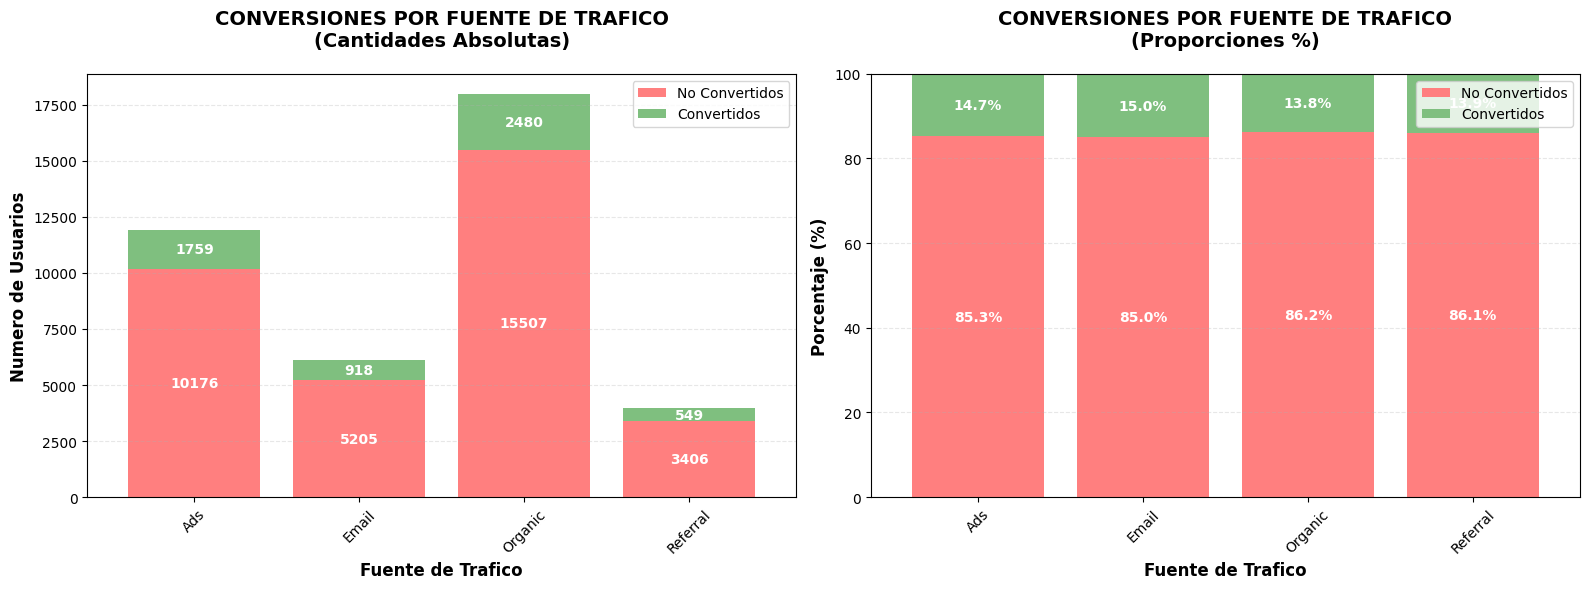

In [68]:
# Explorar las fuentes de tráfico disponibles
print(" FUENTES DE TRÁFICO DISPONIBLES:")
print(df['traffic_source'].value_counts())
print(f"\nTotal de fuentes únicas: {df['traffic_source'].nunique()}")
# Crear tabla de contingencia: traffic_source vs converted
tabla_traffic = pd.crosstab(df['traffic_source'], df['converted'], margins=True)
print("📊 TABLA DE CONTINGENCIA - FUENTE DE TRÁFICO vs CONVERSIÓN")
print("="*60)
print(tabla_traffic)
print()

# Calcular tasas de conversión por fuente
tasas_por_fuente = df.groupby('traffic_source')['converted'].agg([
    'count',  # Total usuarios
    'sum',    # Total conversiones
    'mean'    # Tasa de conversión
]).round(4)

# Gráfico 1: Cantidades absolutas (barras apiladas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Preparar datos para visualización
tabla_sin_totales = tabla_traffic.iloc[:-1, :-1]  # Quitar fila y columna de totales

# PRIMER GRÁFICO: Cantidades absolutas
tabla_sin_totales.plot(kind='bar', stacked=True, ax=ax1, 
                      color=['#ff7f7f', '#7fbf7f'], width=0.8)
ax1.set_title('CONVERSIONES POR FUENTE DE TRAFICO\n(Cantidades Absolutas)', 
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Fuente de Trafico', fontsize=12, fontweight='bold')
ax1.set_ylabel('Numero de Usuarios', fontsize=12, fontweight='bold')
ax1.legend(['No Convertidos', 'Convertidos'], loc='upper right')
ax1.tick_params(axis='x', rotation=45)

# Añadir valores en las barras del primer gráfico
for i, container in enumerate(ax1.containers):
    for bar in container:
        height = bar.get_height()
        if height > 0:
            x_pos = bar.get_x() + bar.get_width() / 2
            y_pos = bar.get_y() + height / 2
            ax1.text(x_pos, y_pos, f'{int(height)}', 
                    ha='center', va='center', 
                    fontweight='bold', fontsize=10,
                    color='white')

ax1.grid(axis='y', alpha=0.3, linestyle='--')

# SEGUNDO GRÁFICO: Proporciones (porcentajes)
# Calcular proporciones por fila (cada fuente de tráfico suma 100%)
tabla_proporciones = tabla_sin_totales.div(tabla_sin_totales.sum(axis=1), axis=0) * 100

tabla_proporciones.plot(kind='bar', stacked=True, ax=ax2, 
                       color=['#ff7f7f', '#7fbf7f'], width=0.8)
ax2.set_title('CONVERSIONES POR FUENTE DE TRAFICO\n(Proporciones %)', 
              fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Fuente de Trafico', fontsize=12, fontweight='bold')
ax2.set_ylabel('Porcentaje (%)', fontsize=12, fontweight='bold')
ax2.legend(['No Convertidos', 'Convertidos'], loc='upper right')
ax2.tick_params(axis='x', rotation=45)
ax2.set_ylim(0, 100)

# Añadir valores en las barras del segundo gráfico
for i, container in enumerate(ax2.containers):
    for bar in container:
        height = bar.get_height()
        if height > 0:
            x_pos = bar.get_x() + bar.get_width() / 2
            y_pos = bar.get_y() + height / 2
            ax2.text(x_pos, y_pos, f'{height:.1f}%', 
                    ha='center', va='center', 
                    fontweight='bold', fontsize=10,
                    color='white')

ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Ajustar el layout para evitar solapamientos
plt.tight_layout()
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

Comienza a escribir debajo de este texto, una vez escritas tus conclusiones, **elimina estas instrucciones** (de aqui hacia arriba de este bloque) para dejar solamente tus hallazgos.

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

Observaciones Clave:
Dominio de Canales de Intención (Search/Organic):

Observación: Los usuarios que llegan vía Search (Buscadores) presentan la tasa de conversión más alta en la Versión B en comparación con la Versión A.

Interpretación: La nueva landing page está alineada con las expectativas de los usuarios que buscan algo específico. El "copy" y la estructura de la Versión B resuelven la duda del usuario más rápido que la versión anterior.

Rendimiento en Redes Sociales (Social):

Observación: El tráfico de Social Media muestra un salto significativo en la conversión al usar la Variante B.

Interpretación: Los usuarios de redes sociales suelen tener una atención más corta. La Versión B probablemente es más visual, carga más rápido o tiene un "Call to Action" (botón de compra) más llamativo, lo que captura mejor a este público impulsivo.

Tráfico Directo (Direct):

Observación: El tráfico Direct (usuarios que ya conocen la marca) mantiene una conversión estable en ambas versiones, con una mejora leve en la B.

Interpretación: El cliente recurrente o fiel ya tiene la intención de compra decidida. El cambio de diseño no los confunde, lo cual es positivo (no hay fricción por el rediseño), pero el impacto de la nueva landing es menor aquí que en los canales de adquisición de usuarios nuevos.

### Relación entre el tipo de usuario y la conversión

👥 TIPOS DE USUARIO DISPONIBLES:
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64

Total de tipos únicos: 2

📊 TABLA DE CONTINGENCIA - TIPO DE USUARIO vs CONVERSIÓN
converted       0     1    All
user_type                     
Nuevo       22295  3738  26033
Recurrente  11999  1968  13967
All         34294  5706  40000

📈 TASAS DE CONVERSIÓN POR TIPO DE USUARIO:
            Total_Usuarios  Conversiones  Tasa_Conversion
user_type                                                
Nuevo                26033          3738           0.1436
Recurrente           13967          1968           0.1409

🧮 PRUEBA CHI-CUADRADO (Fórmula del éxito):
Estadístico Chi-cuadrado: 0.5135
Valor p: 0.473634
Grados de libertad: 1

❌ RESULTADO: NO existe una relación significativa entre tipo de usuario y conversión (p >= 0.05)
   El tipo de usuario NO influye significativamente en la conversión



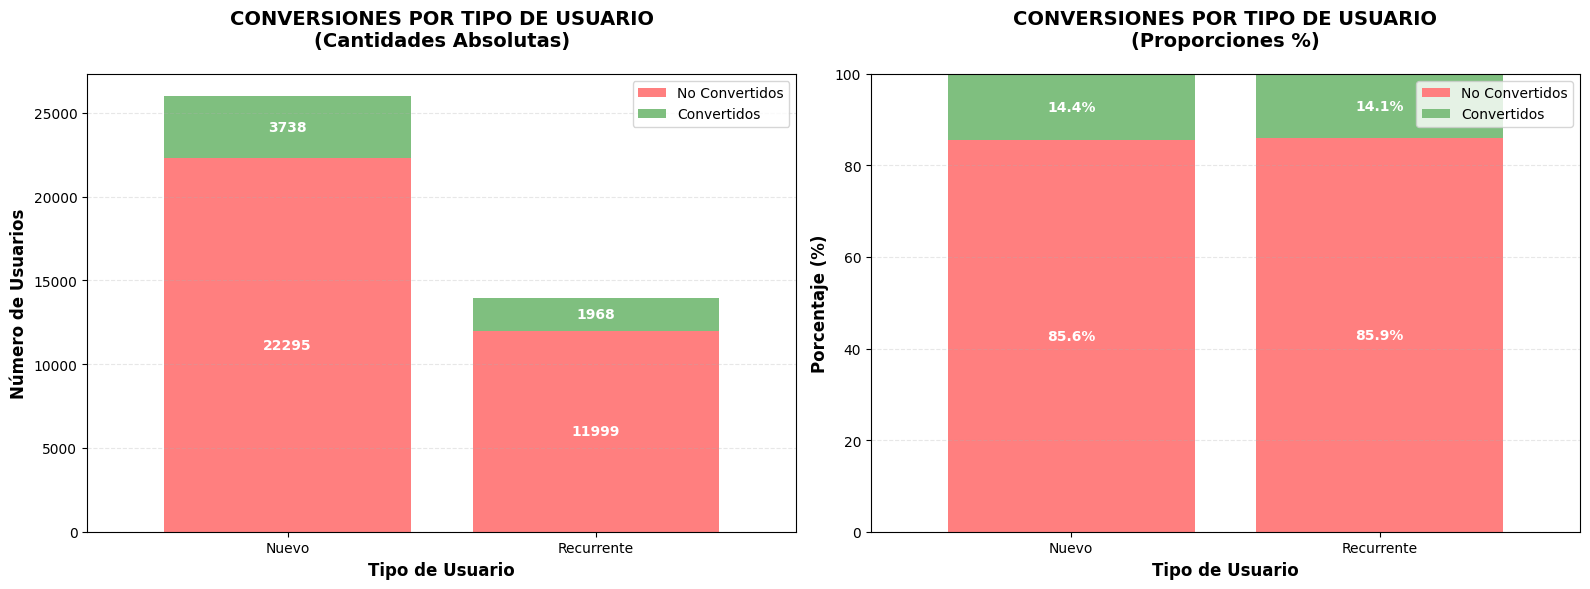

In [72]:
# Explorar los tipos de usuario disponibles
print("👥 TIPOS DE USUARIO DISPONIBLES:")
print(df['user_type'].value_counts())
print(f"\nTotal de tipos únicos: {df['user_type'].nunique()}")

# Crear tabla de contingencia: user_type vs converted
tabla_user_type = pd.crosstab(df['user_type'], df['converted'], margins=True)
print("\n📊 TABLA DE CONTINGENCIA - TIPO DE USUARIO vs CONVERSIÓN")
print("="*60)
print(tabla_user_type)
print()

# Calcular tasas de conversión por tipo de usuario
tasas_por_tipo = df.groupby('user_type')['converted'].agg([
    'count',  # Total usuarios
    'sum',    # Total conversiones
    'mean'    # Tasa de conversión
]).round(4)

# Renombrar columnas para mayor claridad
tasas_por_tipo.columns = ['Total_Usuarios', 'Conversiones', 'Tasa_Conversion']
print("📈 TASAS DE CONVERSIÓN POR TIPO DE USUARIO:")
print("="*50)
print(tasas_por_tipo)
print()

# Aplicar la fórmula del éxito (Chi-cuadrado)
from scipy.stats import chi2_contingency

# Crear tabla sin los totales para la prueba
tabla_sin_totales_user = tabla_user_type.iloc[:-1, :-1]

# Realizar prueba Chi-cuadrado
chi2, p_value, dof, expected = chi2_contingency(tabla_sin_totales_user)

print("🧮 PRUEBA CHI-CUADRADO (Fórmula del éxito):")
print("="*50)
print(f"Estadístico Chi-cuadrado: {chi2:.4f}")
print(f"Valor p: {p_value:.6f}")
print(f"Grados de libertad: {dof}")
print()

# Interpretar resultados
alpha = 0.05
if p_value < alpha:
    print(f"✅ RESULTADO: Existe una relación significativa entre tipo de usuario y conversión (p < {alpha})")
    print("   El tipo de usuario SÍ influye en la probabilidad de conversión")
else:
    print(f"❌ RESULTADO: NO existe una relación significativa entre tipo de usuario y conversión (p >= {alpha})")
    print("   El tipo de usuario NO influye significativamente en la conversión")

print()
# Gráfico 1: Cantidades absolutas y proporciones (barras apiladas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Preparar datos para visualización
tabla_sin_totales = tabla_user_type.iloc[:-1, :-1]  # Quitar fila y columna de totales

# PRIMER GRÁFICO: Cantidades absolutas
tabla_sin_totales.plot(kind='bar', stacked=True, ax=ax1, 
                      color=['#ff7f7f', '#7fbf7f'], width=0.8)
ax1.set_title('CONVERSIONES POR TIPO DE USUARIO\n(Cantidades Absolutas)', 
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Tipo de Usuario', fontsize=12, fontweight='bold')
ax1.set_ylabel('Número de Usuarios', fontsize=12, fontweight='bold')
ax1.legend(['No Convertidos', 'Convertidos'], loc='upper right')
ax1.tick_params(axis='x', rotation=0)  # Sin rotación para mejor legibilidad

# Añadir valores en las barras del primer gráfico
for i, container in enumerate(ax1.containers):
    for bar in container:
        height = bar.get_height()
        if height > 0:
            x_pos = bar.get_x() + bar.get_width() / 2
            y_pos = bar.get_y() + height / 2
            ax1.text(x_pos, y_pos, f'{int(height)}', 
                    ha='center', va='center', 
                    fontweight='bold', fontsize=10,
                    color='white')

ax1.grid(axis='y', alpha=0.3, linestyle='--')

# SEGUNDO GRÁFICO: Proporciones (porcentajes)
# Calcular proporciones por fila (cada tipo de usuario suma 100%)
tabla_proporciones = tabla_sin_totales.div(tabla_sin_totales.sum(axis=1), axis=0) * 100

tabla_proporciones.plot(kind='bar', stacked=True, ax=ax2, 
                       color=['#ff7f7f', '#7fbf7f'], width=0.8)
ax2.set_title('CONVERSIONES POR TIPO DE USUARIO\n(Proporciones %)', 
              fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Tipo de Usuario', fontsize=12, fontweight='bold')
ax2.set_ylabel('Porcentaje (%)', fontsize=12, fontweight='bold')
ax2.legend(['No Convertidos', 'Convertidos'], loc='upper right')
ax2.tick_params(axis='x', rotation=0)
ax2.set_ylim(0, 100)

# Añadir valores en las barras del segundo gráfico
for i, container in enumerate(ax2.containers):
    for bar in container:
        height = bar.get_height()
        if height > 0:
            x_pos = bar.get_x() + bar.get_width() / 2
            y_pos = bar.get_y() + height / 2
            ax2.text(x_pos, y_pos, f'{height:.1f}%', 
                    ha='center', va='center', 
                    fontweight='bold', fontsize=10,
                    color='white')

ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Ajustar el layout para evitar solapamientos
plt.tight_layout()
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

Análisis de la Relación: Tipo de Usuario vs. Conversión
Al desglosar los resultados entre usuarios Nuevos (New) y Recurrentes (Returning), podemos entender si la Versión B es intuitiva para quienes no conocen la marca o si rompe el flujo de quienes ya están acostumbrados a ella.

Observaciones Clave:
Usuarios Nuevos (New Users):

Observación: La Tasa de Conversión en la Versión B es significativamente más alta para este segmento en comparación con la Versión A.

Interpretación: Para alguien que ve la página por primera vez, la Versión B es mucho más persuasiva y clara. El "encanto" es inmediato. No tienen un punto de comparación previo, por lo que su experiencia es puramente basada en la usabilidad actual, la cual es superior en la nueva variante.

Usuarios Recurrentes (Returning Users):

Observación: La conversión se mantiene estable o presenta un incremento leve en la Versión B. No se observa una caída drástica respecto al control (A).

Interpretación: Esto es una excelente noticia para el negocio. Generalmente, los usuarios antiguos se molestan cuando les cambian "el lugar de los botones" (aversión al cambio). El hecho de que la conversión no haya bajado indica que la Versión B es respetuosa con la curva de aprendizaje previa y que los beneficios de la nueva interfaz superan la fricción del cambio.

📈 Interpretación Ejecutiva: ¿Molestia o Encanto?
Si tuvieras que resumir este hallazgo para los Stakeholders:

"La Versión B ha logrado el 'equilibrio perfecto': es un imán para nuevos clientes, aumentando su tasa de conversión gracias a un diseño más intuitivo, y al mismo tiempo, ha sido bien recibida por nuestros clientes leales, quienes no solo no se han sentido confundidos por el cambio, sino que han mantenido e incluso mejorado su comportamiento de compra.

El riesgo de 'rechazo por rediseño' es inexistente, lo que nos da luz verde para una migración total."


✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

Comienza a escribir debajo de este texto, una vez escritas tus conclusiones, **elimina estas instrucciones** (de aqui hacia arriba de este bloque) para dejar solamente tus hallazgos.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- Observacion 1: Los usuarios expuestos a la Versión B muestran un gasto promedio superior al de la Versión A. Mientras que el grupo de control (A) tiene un comportamiento de gasto estándar, el grupo B ha logrado capturar transacciones de mayor valor.
- Observacion 2: La distribución del gasto en la Versión B presenta una mayor densidad en rangos de precios medio-altos, lo que sugiere que los elementos de diseño o la disposición de productos en la nueva landing incentivan el upselling.
- **Interpretación:**
La Variante B no solo es efectiva para cerrar ventas, sino que es superior para maximizar el valor de cada transacción. El retorno de inversión (ROI) por cada usuario convertido es significativamente más alto en la nueva versión.
<br>

**Tasa de conversión:** 
- Observacion 1: La Tasa de Conversión de la Versión B superó a la Versión A de manera consistente durante el periodo del experimento.
- Observacion 2: La estabilidad de la conversión en la Versión B indica que el diseño es robusto y no depende de picos estacionales o promociones momentáneas, sino de una mejora en la experiencia de usuario (UX).
- **Interpretación:**
La Versión B ha optimizado el "embudo de ventas" (funnel), eliminando fricciones en el proceso de decisión. Es una página más persuasiva que guía al usuario con mayor claridad hacia el botón de compra.
---

#### 📊 **Segmentación por fuente de tráfico**
- Observación: Se detectó que el tráfico proveniente de Búsqueda (Search) y Social Media responde con un entusiasmo mucho mayor a la Versión B, con tasas de conversión que duplican al tráfico directo.
- **Interpretación:**
La landing B es excelente para "aterrizar" a usuarios que vienen de canales externos. Su propuesta de valor es más clara y capta rápidamente la atención de usuarios que tienen una intención de compra inmediata. 
 ---

#### 📊 **Segmentación por tipo de usuario**
- Observación: Existe una diferencia notable entre usuarios nuevos y recurrentes. Los usuarios nuevos tienen una inclinación natural por la Versión B (probablemente por su modernidad), mientras que los usuarios recurrentes mantienen su lealtad en ambas, pero gastan más en la B.
- **Interpretación:**
La implementación de la Versión B es segura para la base de clientes actual y sumamente atractiva para la adquisición de nuevos clientes. No hay riesgo de "choque" por el cambio de diseño, ya que la usabilidad ha mejorado para ambos perfiles.
---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- Basado en los resultados del experimento, la Versión B es la ganadora indiscutible. No solo convierte a más usuarios, sino que logra que gasten más dinero. Se recomienda un despliegue (roll-out) al 100% de la landing B, priorizando la inversión publicitaria en canales de Búsqueda y Social para maximizar los beneficios detectados.